# How LLMs "See" Text — Tokenization & Embeddings

**Advanced NLP Course — Exercise Session**  
Leibniz Universität Hannover

---

### What you will learn

1. **Tokenization** — How text is split into tokens, and why it matters
2. **Vocabulary & Token IDs** — The bridge between text and numbers
3. **Embeddings** — Turning tokens into vectors with meaning
4. **Semantic Search** — Finding similar sentences using cosine similarity
5. **Embedding Arithmetic** — The classic `king - man + woman = queen` trick
6. **Multilingual Embeddings** — Do German and English land in the same space?

### Libraries used
- `transformers` (HuggingFace) — tokenizers & models
- `sentence-transformers` — state-of-the-art sentence embeddings
- `tokenizers` — fast BPE tokenizer inspection
- `matplotlib` + `scikit-learn` — visualisation

---
> **Tip:** Run each cell top-to-bottom. Every section has a small exercise for you — look for the 🏋️ emoji!

## 0 · Installation & Imports

In [ ]:
# Install required libraries (run once)
!pip install transformers sentence-transformers tokenizers scikit-learn matplotlib seaborn --quiet

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

from transformers import AutoTokenizer
from sentence_transformers import SentenceTransformer

import torch

print("✅ All imports successful!")
print(f"   PyTorch version : {torch.__version__}")
print(f"   CUDA available  : {torch.cuda.is_available()}")

2026-04-28 07:23:19.511336: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 07:23:19.614270: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-28 07:23:32.072748: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ All imports successful!
   PyTorch version : 2.9.1+cu128
   CUDA available  : True


---
## 1 · Tokenization — How LLMs Read Text

LLMs don't read words — they read **tokens**.  
A token is roughly a word-piece, produced by algorithms like **Byte-Pair Encoding (BPE)** (used by LLaMA, GPT) or **WordPiece** (used by BERT).

Let's see what that looks like in practice.

In [ ]:
# Load the tokenizer from GPT-2 (BPE, same family as LLaMA)
tokenizer_gpt2 = AutoTokenizer.from_pretrained("gpt2")

# Load the tokenizer from BERT (WordPiece)
tokenizer_bert = AutoTokenizer.from_pretrained("bert-base-uncased")

print(f"GPT-2 vocabulary size : {tokenizer_gpt2.vocab_size:,} tokens")
print(f"BERT  vocabulary size : {tokenizer_bert.vocab_size:,} tokens")

GPT-2 vocabulary size : 50,257 tokens
BERT  vocabulary size : 30,522 tokens


In [ ]:
def show_tokens(text, tokenizer, name):
    """Pretty-print tokenization with coloured boxes."""
    tokens = tokenizer.tokenize(text)
    ids    = tokenizer.encode(text, add_special_tokens=False)

    print(f"\n{'═'*60}")
    print(f"  Tokenizer : {name}")
    print(f"  Input     : \"{text}\"")
    print(f"  # Tokens  : {len(tokens)}")
    print(f"{'─'*60}")

    for tok, id_ in zip(tokens, ids):
        print(f"  {str(id_):>6}  │  {tok}")
    print(f"{'═'*60}")

sentence = "The Leibniz Universität Hannover is a great place for NLP research!"

show_tokens(sentence, tokenizer_gpt2, "GPT-2 (BPE)")
show_tokens(sentence, tokenizer_bert, "BERT (WordPiece)")


════════════════════════════════════════════════════════════
  Tokenizer : GPT-2 (BPE)
  Input     : "The Leibniz Universität Hannover is a great place for NLP research!"
  # Tokens  : 20
────────────────────────────────────────────────────────────
     464  │  The
    1004  │  ĠLe
     571  │  ib
      77  │  n
     528  │  iz
   26986  │  ĠUnivers
     270  │  it
   11033  │  Ã¤
      83  │  t
   14353  │  ĠHann
    2502  │  over
     318  │  Ġis
     257  │  Ġa
    1049  │  Ġgreat
    1295  │  Ġplace
     329  │  Ġfor
     399  │  ĠN
   19930  │  LP
    2267  │  Ġresearch
       0  │  !
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  Tokenizer : BERT (WordPiece)
  Input     : "The Leibniz Universität Hannover is a great place for NLP research!"
  # Tokens  : 18
────────────────────────────────────────────────────────────
    1996  │  the
   26947  │  lei
   24700  │  ##bn
   10993  │  ##iz
    4895  │  un


In [ ]:
# LLaMA splits every digit individually — let's see how GPT-2 handles numbers
number_texts = [
    "The year is 2024.",
    "Pi is approximately 3.14159265.",
    "The model has 70,000,000,000 parameters."
]

print("\n📊 How GPT-2 tokenizes numbers:\n")
for text in number_texts:
    toks = tokenizer_gpt2.tokenize(text)
    print(f"  '{text}'")
    print(f"  → {toks}")
    print(f"  → {len(toks)} tokens\n")


📊 How GPT-2 tokenizes numbers:

  'The year is 2024.'
  → ['The', 'Ġyear', 'Ġis', 'Ġ2024', '.']
  → 5 tokens

  'Pi is approximately 3.14159265.'
  → ['Pi', 'Ġis', 'Ġapproximately', 'Ġ3', '.', '14', '159', '265', '.']
  → 9 tokens

  'The model has 70,000,000,000 parameters.'
  → ['The', 'Ġmodel', 'Ġhas', 'Ġ70', ',', '000', ',', '000', ',', '000', 'Ġparameters', '.']
  → 12 tokens



In [ ]:
# English-centric tokenizers are INEFFICIENT on other languages

translations = {
    "English"  : "The cat sat on the mat.",
    "German"   : "Die Katze saß auf der Matte.",
    "Arabic"   : "الجلست القطة على الحصيرة.",
    "Chinese"  : "猫坐在垫子上。",
    "Japanese" : "猫はマットの上に座った。",
}

print("\n🌍 Token count for the same sentence in different languages (GPT-2):\n")
results = []
for lang, text in translations.items():
    toks = tokenizer_gpt2.tokenize(text)
    results.append((lang, len(toks), text))
    print(f"  {lang:10s} → {len(toks):3d} tokens   '{text}'")

print("\n💡 English needs the fewest tokens — GPT-2 was trained mostly on English data!")


🌍 Token count for the same sentence in different languages (GPT-2):

  English    →   7 tokens   'The cat sat on the mat.'
  German     →  10 tokens   'Die Katze saß auf der Matte.'
  Arabic     →  26 tokens   'الجلست القطة على الحصيرة.'
  Chinese    →  14 tokens   '猫坐在垫子上。'
  Japanese   →  14 tokens   '猫はマットの上に座った。'

💡 English needs the fewest tokens — GPT-2 was trained mostly on English data!


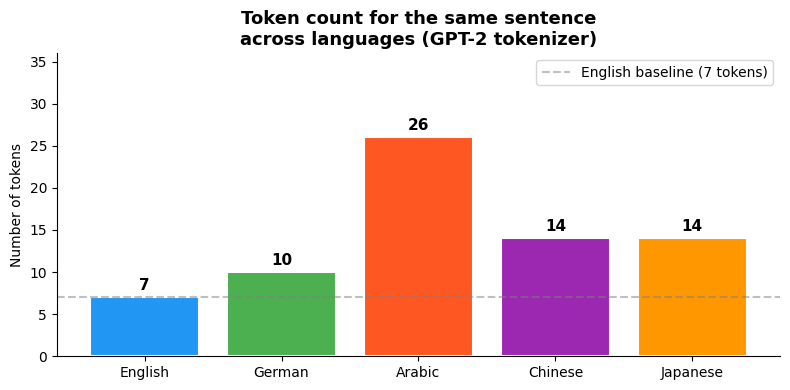

In [ ]:
# Visualise token counts
langs  = [r[0] for r in results]
counts = [r[1] for r in results]
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(langs, counts, color=colors, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, padding=3, fontsize=11, fontweight='bold')
ax.set_title('Token count for the same sentence\nacross languages (GPT-2 tokenizer)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of tokens')
ax.set_ylim(0, max(counts) + 10)
ax.axhline(y=counts[0], color='gray', linestyle='--', alpha=0.5, label=f'English baseline ({counts[0]} tokens)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# This is EXACTLY why the showed Qwen's improved multilingual domains!

### 🏋️ Exercise 1.1

Try tokenizing your own name and your hometown with GPT-2.  
- Is your name a single token or multiple tokens?
- What about rare words like `Schadenfreude` or `Weltanschauung`?

In [ ]:
# YOUR CODE HERE
your_name = "Hannover"  # ← change this!
rare_word  = "Schadenfreude"  # ← try different words!

show_tokens(your_name, tokenizer_gpt2, "GPT-2")
show_tokens(rare_word,  tokenizer_gpt2, "GPT-2")

---
## 2 · Sentence Embeddings with `sentence-transformers`

Embeddings map text to **dense vectors** in a high-dimensional space.  
The key idea: **semantically similar sentences → nearby vectors**.

We'll use `all-MiniLM-L6-v2` — a tiny but powerful model (80 MB) that produces 384-dimensional embeddings.

reference: https://www.sbert.net/index.html

In [ ]:
# Load a small but powerful sentence embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"✅ Model loaded")
print(f"   Embedding dimensions: {model.get_sentence_embedding_dimension()}")

✅ Model loaded
   Embedding dimensions: 384


In [ ]:
# Basic embedding
sentences = [
    "A dog is running in the park.",
    "A puppy is playing outside.",
    "The stock market crashed today.",
    "Investors lost billions on Wall Street.",
    "The Eiffel Tower is in Paris.",
    "Paris is the capital of France.",
    "I love eating pizza.",
    "My favourite food is pasta.",
]

embeddings = model.encode(sentences, show_progress_bar=False)
print(f"Embedding matrix shape: {embeddings.shape}")
print(f"  {len(sentences)} sentences × {embeddings.shape[1]} dimensions")

Embedding matrix shape: (8, 384)
  8 sentences × 384 dimensions


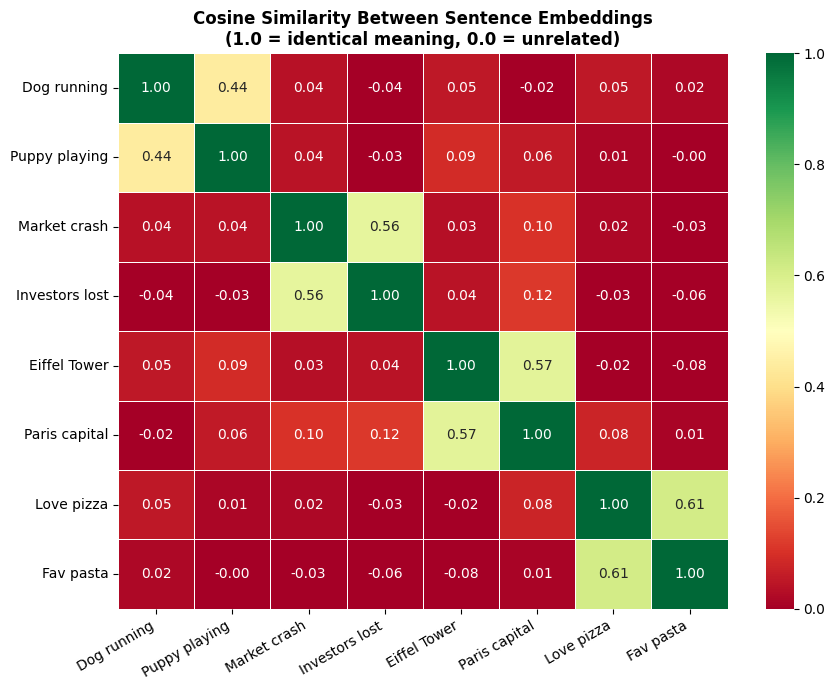


🔍 Notice: sentence PAIRS (dog/puppy, market/investors, etc.) have high similarity!


In [ ]:
# Cosine Similarity Heatmap
cos_sim = cosine_similarity(embeddings)

# Short labels for the heatmap
labels = [
    "Dog running", "Puppy playing",
    "Market crash", "Investors lost",
    "Eiffel Tower", "Paris capital",
    "Love pizza", "Fav pasta"
]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cos_sim,
    xticklabels=labels, yticklabels=labels,
    annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.5,
    ax=ax
)
ax.set_title('Cosine Similarity Between Sentence Embeddings\n(1.0 = identical meaning, 0.0 = unrelated)',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n🔍 Notice: sentence PAIRS (dog/puppy, market/investors, etc.) have high similarity!")

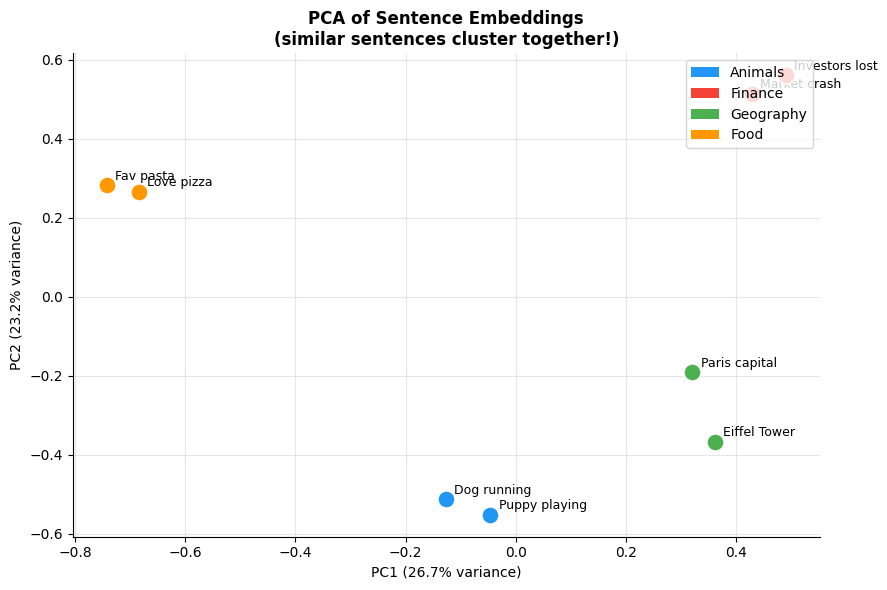

In [ ]:
# PCA Visualisation — See the clusters!
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

topics = ['Animals', 'Animals', 'Finance', 'Finance', 'Geography', 'Geography', 'Food', 'Food']
colors_map = {'Animals': '#2196F3', 'Finance': '#F44336', 'Geography': '#4CAF50', 'Food': '#FF9800'}

fig, ax = plt.subplots(figsize=(9, 6))
for i, (x, y) in enumerate(reduced):
    color = colors_map[topics[i]]
    ax.scatter(x, y, c=color, s=150, zorder=3, edgecolors='white', linewidth=1)
    ax.annotate(labels[i], (x, y), fontsize=9,
                xytext=(6, 4), textcoords='offset points')

# Add topic legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in colors_map.items()]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax.set_title('PCA of Sentence Embeddings\n(similar sentences cluster together!)',
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3 · Semantic Search — Finding Relevant Sentences

This is the backbone of **Retrieval-Augmented Generation (RAG)**.  
Given a query, find the most relevant documents by comparing embeddings.

In [ ]:
# A tiny "knowledge base"
knowledge_base = [
    "Pre-training is the first stage where LLMs learn general language from massive corpora.",
    "The LLaMA model was released by Meta and trained on 1.4 trillion tokens.",
    "RLHF stands for Reinforcement Learning from Human Feedback.",
    "Byte-Pair Encoding (BPE) is a tokenization algorithm that merges frequent character pairs.",
    "Scaling laws describe how model performance improves with more parameters and data.",
    "Grouped Query Attention (GQA) reduces memory usage during inference.",
    "Supervised Fine-Tuning (SFT) teaches the model to follow instructions.",
    "Common Crawl is a large web dataset used to train many LLMs.",
    "The Pile is an 800 GB dataset created by EleutherAI for LM training.",
    "Data parallelism replicates the model on each GPU and splits the training data.",
    "Pipeline parallelism splits model layers across different GPUs.",
    "ZeRO (Zero Redundancy Optimizer) reduces memory by sharding optimizer states.",
]

# Encode the knowledge base
kb_embeddings = model.encode(knowledge_base, show_progress_bar=False)
print(f"Knowledge base encoded: {kb_embeddings.shape}")

Knowledge base encoded: (12, 384)


In [ ]:
def semantic_search(query, kb_embeddings, knowledge_base, top_k=3):
    """Find the top_k most relevant sentences for a query."""
    query_emb = model.encode([query], show_progress_bar=False)
    scores    = cosine_similarity(query_emb, kb_embeddings)[0]
    top_idx   = np.argsort(scores)[::-1][:top_k]

    print(f"\n🔍 Query : '{query}'")
    print(f"{'─'*65}")
    for rank, idx in enumerate(top_idx, 1):
        print(f"  #{rank}  Score: {scores[idx]:.3f}")
        print(f"      {knowledge_base[idx]}")

# Run some queries!
queries = [
    "How do you save GPU memory when training large models?",
    "What data was LLaMA trained on?",
    "How does tokenization work?",
]

for q in queries:
    semantic_search(q, kb_embeddings, knowledge_base)


🔍 Query : 'How do you save GPU memory when training large models?'
─────────────────────────────────────────────────────────────────
  #1  Score: 0.601
      Data parallelism replicates the model on each GPU and splits the training data.
  #2  Score: 0.496
      Pipeline parallelism splits model layers across different GPUs.
  #3  Score: 0.312
      The Pile is an 800 GB dataset created by EleutherAI for LM training.

🔍 Query : 'What data was LLaMA trained on?'
─────────────────────────────────────────────────────────────────
  #1  Score: 0.666
      The LLaMA model was released by Meta and trained on 1.4 trillion tokens.
  #2  Score: 0.424
      Common Crawl is a large web dataset used to train many LLMs.
  #3  Score: 0.377
      The Pile is an 800 GB dataset created by EleutherAI for LM training.

🔍 Query : 'How does tokenization work?'
─────────────────────────────────────────────────────────────────
  #1  Score: 0.407
      Byte-Pair Encoding (BPE) is a tokenization algorithm that

### 🏋️ Exercise 3.1

Add 3 more sentences to the `knowledge_base` about topics from the lecture (e.g., about Mixtral's Mixture of Experts, or about FineWeb-Edu). Then query for something related and check if your new entries are retrieved!

In [ ]:
# YOUR CODE HERE
my_new_facts = [
    # Add your sentences here!
    "Mixtral uses a Mixture of Experts architecture with 8 expert feed-forward layers.",
    # "...",
    # "...",
]

extended_kb      = knowledge_base + my_new_facts
extended_embs    = model.encode(extended_kb, show_progress_bar=False)

semantic_search("What is special about Mixtral's architecture?", extended_embs, extended_kb)

---
## 4 · The Famous Embedding Arithmetic

A classic demonstration: you can **do maths with word meanings**.  
`vector(king) - vector(man) + vector(woman) ≈ vector(queen)`

Let's verify this with modern sentence embeddings.

In [ ]:
# For word-level analogy we use a transformer that produces word embeddings
# We'll use the [CLS] token of BERT as a word representation trick,
# but sentence-transformers also works well here

# Word analogies with sentence embeddings
analogy_words = ["king", "queen", "man", "woman",
                 "Paris", "London", "France", "England",
                 "teacher", "student", "school", "university",
                 "hot", "cold", "summer", "winter"]

word_embeddings = model.encode(analogy_words, show_progress_bar=False)
word_emb_dict   = {w: e for w, e in zip(analogy_words, word_embeddings)}

def analogy(a, b, c, top_k=5):
    """
    a - b + c = ?
    Classic analogy: king - man + woman = queen
    """
    target = word_emb_dict[a] - word_emb_dict[b] + word_emb_dict[c]
    target = target / np.linalg.norm(target)  # normalise

    # Find closest in our small vocabulary (excluding input words)
    exclude = {a, b, c}
    scores  = {}
    for w, e in word_emb_dict.items():
        if w not in exclude:
            sim = cosine_similarity([target], [e])[0][0]
            scores[w] = sim

    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]

    print(f"\n📐 Analogy: {a} − {b} + {c} = ?")
    for w, s in ranked:
        bar = '█' * int(s * 30)
        print(f"   {w:15s}  {s:.3f}  {bar}")

analogy("king",   "man",     "woman")
analogy("Paris",  "France",  "England")
analogy("teacher","school",  "university")


📐 Analogy: king − man + woman = ?
   queen            0.579  █████████████████
   teacher          0.392  ███████████
   France           0.311  █████████
   winter           0.257  ███████
   cold             0.241  ███████

📐 Analogy: Paris − France + England = ?
   London           0.731  █████████████████████
   school           0.383  ███████████
   university       0.347  ██████████
   queen            0.324  █████████
   summer           0.277  ████████

📐 Analogy: teacher − school + university = ?
   student          0.569  █████████████████
   woman            0.340  ██████████
   queen            0.321  █████████
   king             0.264  ███████
   London           0.229  ██████


---
## 5 · Multilingual Embeddings — Do Languages Share the Same Space?

Modern multilingual models (like `paraphrase-multilingual-MiniLM-L12-v2`) are trained to map the **same meaning in different languages to the same vector**.

Let's test this!

In [ ]:
# Load a multilingual sentence embedding model
ml_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print(f"✅ Multilingual model loaded")
print(f"   Dimensions: {ml_model.get_sentence_embedding_dimension()}")
print(f"   Supports 50+ languages!")

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

In [ ]:
# Same concept expressed in 5 languages
multilingual_sentences = {
    # Topic: AI / Machine Learning
    "EN: AI": "Artificial intelligence will change the world.",
    "DE: AI": "Künstliche Intelligenz wird die Welt verändern.",
    "FR: AI": "L'intelligence artificielle va changer le monde.",
    "ES: AI": "La inteligencia artificial cambiará el mundo.",
    "ZH: AI": "人工智能将改变世界。",
    # Topic: Food
    "EN: Food": "I love eating Italian food.",
    "DE: Food": "Ich liebe italienisches Essen.",
    "FR: Food": "J'adore la cuisine italienne.",
    "ES: Food": "Me encanta la comida italiana.",
    "ZH: Food": "我喜欢吃意大利食物。",
}

labels_ml = list(multilingual_sentences.keys())
texts_ml  = list(multilingual_sentences.values())

embs_ml   = ml_model.encode(texts_ml, show_progress_bar=False)
sim_ml    = cosine_similarity(embs_ml)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_ml,
    xticklabels=labels_ml, yticklabels=labels_ml,
    annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0.0, vmax=1.0, linewidths=0.5,
    ax=ax
)
ax.set_title('Cross-lingual Similarity\n(Same meaning → high score, even across languages!)',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n🌍 The top-left 5×5 block and bottom-right 5×5 block should be brighter")
print("   — showing that same-topic sentences cluster regardless of language!")

In [ ]:
# t-SNE to see language-agnostic semantic clusters
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
reduced_ml = tsne.fit_transform(embs_ml)

# Colours by topic, markers by language
topic_colors = {'AI': '#E91E63', 'Food': '#2196F3'}
lang_markers = {'EN': 'o', 'DE': 's', 'FR': '^', 'ES': 'D', 'ZH': 'P'}

fig, ax = plt.subplots(figsize=(9, 6))

for i, label in enumerate(labels_ml):
    lang, topic = label.split(': ')
    x, y = reduced_ml[i]
    ax.scatter(x, y,
               c=topic_colors[topic],
               marker=lang_markers[lang],
               s=200, zorder=3,
               edgecolors='white', linewidth=1.5)
    ax.annotate(label, (x, y), fontsize=8,
                xytext=(5, 3), textcoords='offset points')

# Legend
from matplotlib.lines import Line2D
legend_elements = (
    [Patch(facecolor=c, label=t) for t, c in topic_colors.items()] +
    [Line2D([0],[0], marker=m, color='gray', markersize=8, label=l, linestyle='None')
     for l, m in lang_markers.items()]
)
ax.legend(handles=legend_elements, loc='best', fontsize=9, ncol=2)
ax.set_title('t-SNE of Multilingual Embeddings\n(colour = topic, shape = language)',
             fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### 🏋️ Exercise 5.1 — Cross-lingual Retrieval

**Task:** Write a German query and retrieve matching English sentences (or vice-versa) from a mixed-language knowledge base. This is called **cross-lingual retrieval** and is very useful in practice!

In [ ]:
# 🏋️ YOUR CODE HERE

# Mixed language knowledge base
mixed_kb = [
    "Large language models are pre-trained on massive text corpora.",       # EN
    "Sprachmodelle lernen Grammatik und Fakten während des Vortrainings.",  # DE
    "Les modèles de langue utilisent l'attention pour comprendre le texte.",# FR
    "Tokenization splits text into smaller units called tokens.",           # EN
    "Die Tokenisierung zerlegt Text in kleinere Einheiten.",                # DE
    "Scaling laws predict model performance based on compute and data.",    # EN
]

mixed_embs = ml_model.encode(mixed_kb, show_progress_bar=False)

# Query in German, retrieve from the mixed KB
german_query = "Wie funktioniert das Training von Sprachmodellen?"

q_emb  = ml_model.encode([german_query], show_progress_bar=False)
scores = cosine_similarity(q_emb, mixed_embs)[0]
ranked = np.argsort(scores)[::-1]

print(f"🔍 Query (German): '{german_query}'\n")
for idx in ranked:
    print(f"  Score: {scores[idx]:.3f}  →  {mixed_kb[idx]}")

---
## Summary & Key Takeaways

| Concept | What we learned |
|---|---|
| **Tokenization** | Text → token IDs via BPE or WordPiece; non-English languages cost more tokens |
| **Embeddings** | High-dimensional vectors encoding semantic meaning |
| **Cosine similarity** | Measures "closeness" of meaning between embeddings |
| **Semantic search** | Query → embedding → nearest neighbours = RAG building block |
| **Multilingual embeddings** | Cross-lingual models map same meaning to same region |


---
*Advanced NLP · Exercise Session · Leibniz Universität Hannover